In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducible random numbers
np.random.seed(42)

# 1. Generate Dates for Two Semesters (Excluding the long break in between)
# Semester 1: Feb to June
sem1_dates = pd.date_range(start='2025-02-17', end='2025-06-06')
# Semester 2: August to December
sem2_dates = pd.date_range(start='2025-08-18', end='2025-12-05')

# Combine both semesters into one timeline
all_dates = sem1_dates.union(sem2_dates)

# 2. Create Base DataFrame
df = pd.DataFrame({'Date': all_dates})
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Semester'] = np.where(df['Date'] < '2025-07-01', 1, 2)

# 3. Add Specific Menu Items
starches = ['Sadza', 'Rice']
proteins = ['Chicken', 'Beef', 'Beans', 'Soya']
sides = ['Vegs', 'Salad']

# Randomly assign one of each category per day
df['Starch'] = np.random.choice(starches, size=len(df))
df['Protein'] = np.random.choice(proteins, size=len(df))
df['Side'] = np.random.choice(sides, size=len(df))

# Create a full menu string for easy reading during EDA
df['Full_Menu'] = df['Starch'] + ', ' + df['Protein'] + ' & ' + df['Side']

# 4. Add Academic Calendar Events (Exam weeks at the end of each semester)
events = ['Regular'] * len(df)
sem1_exam_start = pd.to_datetime('2025-05-26')
sem2_exam_start = pd.to_datetime('2025-11-24')

for i, date in enumerate(df['Date']):
    if sem1_exam_start <= date <= pd.to_datetime('2025-06-06'):
        events[i] = 'Exam Week'
    elif sem2_exam_start <= date <= pd.to_datetime('2025-12-05'):
        events[i] = 'Exam Week'
        
df['Academic_Event'] = events

# 5. Generate the Target Variable: "Meals_Served"
base_demand = 850

def calculate_demand(row):
    demand = base_demand
    
    # Trend 1: Weekend drop-off
    if row['Day_of_Week'] in ['Saturday', 'Sunday']:
        demand -= 400
        
    # Trend 2: Protein popularity (Meat drives higher attendance than plant-based)
    if row['Protein'] == 'Beef':
        demand += 150
    elif row['Protein'] == 'Chicken':
        demand += 120
    elif row['Protein'] == 'Beans':
        demand -= 60
    elif row['Protein'] == 'Soya':
        demand -= 90
        
    # Trend 3: Starch preference
    if row['Starch'] == 'Rice':
        demand += 40 
        
    # Trend 4: Calendar impacts
    if row['Academic_Event'] == 'Exam Week':
        demand -= 150 
        
    # Add random noise for realism
    noise = np.random.randint(-50, 50)
    
    return max(0, demand + noise)

df['Meals_Served'] = df.apply(calculate_demand, axis=1)

# 6. Save the dataset to CSV
df.to_csv('msu_dining_2semesters.csv', index=False)
print("Dataset successfully generated and saved as 'msu_dining_2semesters.csv'")

Dataset successfully generated and saved as 'msu_dining_2semesters.csv'


#### 1. EXPLORATORY DATA ANALYSIS (EDA) - Imports and Load

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Set a consistent visual style for all plots.
sns.set_theme(style="whitegrid")

# Load the dining hall dataset. Use the CSV file (run the cell above first to generate it, or ensure the file exists).
df = pd.read_csv('msu_dining_2semesters.csv')

# Convert Date to datetime so we can sort and plot time series correctly.
df['Date'] = pd.to_datetime(df['Date'])

# Quick look at structure and first rows.
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (220, 9)

First few rows:


,Date,Day_of_Week,Semester,Starch,Protein,Side,Full_Menu,Academic_Event,Meals_Served
0,2025-02-17,Monday,1,Sadza,Beans,Vegs,"Sadza, Beans & Vegs",Regular,755
1,2025-02-18,Tuesday,1,Rice,Beans,Salad,"Rice, Beans & Salad",Regular,830
2,2025-02-19,Wednesday,1,Sadza,Beef,Vegs,"Sadza, Beef & Vegs",Regular,1035
3,2025-02-20,Thursday,1,Sadza,Soya,Salad,"Sadza, Soya & Salad",Regular,766
4,2025-02-21,Friday,1,Sadza,Beef,Salad,"Sadza, Beef & Salad",Regular,978


#### EDA: Bar Chart - Average Meals_Served by Protein 

This bar chart shows that protein choice is linked to demand. Meat options (e.g. Beef, Chicken) typically have higher average meals served than plant-based options (Beans, Soya), suggesting student preferences influence dining hall traffic. 

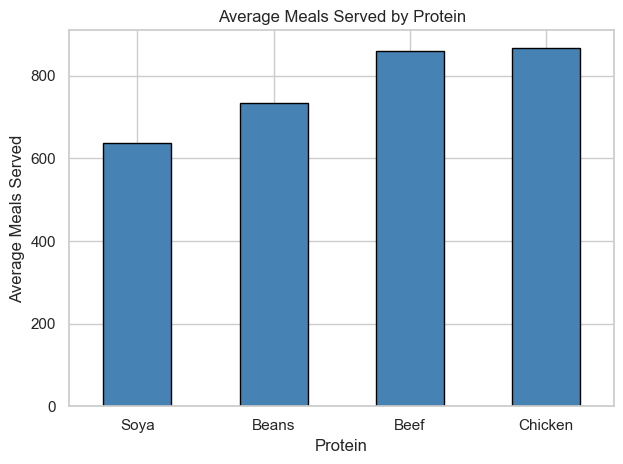

Interpretation: This bar chart shows that protein choice is linked to demand. Meat options (e.g. Beef, Chicken) typically have higher average meals served than plant-based options (Beans, Soya), suggesting student preferences influence dining hall traffic.


In [ ]:
# =============================================================================
# 
# =============================================================================
# See which protein options are associated with higher or lower average demand.
avg_by_protein = df.groupby('Protein')['Meals_Served'].mean().sort_values()
avg_by_protein.plot(kind='bar', xlabel='Protein', ylabel='Average Meals Served', title='Average Meals Served by Protein', color='steelblue', edgecolor='black')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



##### The boxplot shows that weekday demand is generally higher and less variable than weekend demand Weekends tend to have lower median meals served and often a wider spread, reflecting fewer students on campus.

#### EDA: Boxplot - Meals_Served on Weekdays vs Weekends (using Day_of_Week)

C:\Users\asus\AppData\Local\Temp\ipykernel_12856\2698304909.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Weekday_Type', y='Meals_Served', palette='Set2')


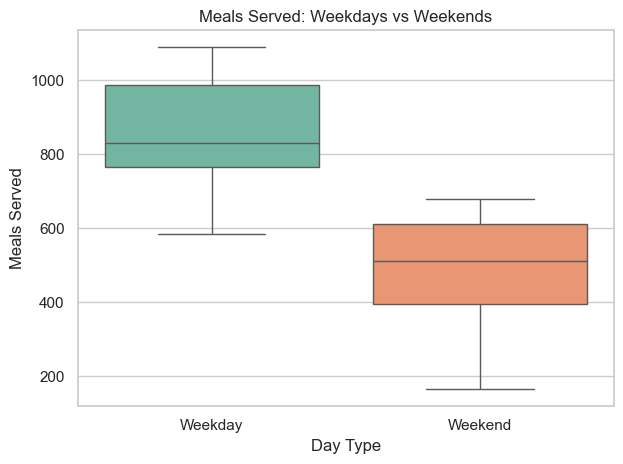

Interpretation: The boxplot shows that weekday demand is generally higher and less variable than weekend demand. Weekends tend to have lower median meals served and often a wider spread, reflecting fewer students on campus.


In [ ]:
# Create a binary grouping from Day_of_Week for a clear weekday vs weekend comparison.
df['Weekday_Type'] = df['Day_of_Week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

sns.boxplot(data=df, x='Weekday_Type', y='Meals_Served', palette='Set2')
plt.title('Meals Served: Weekdays vs Weekends')
plt.xlabel('Day Type')
plt.ylabel('Meals Served')
plt.tight_layout()
plt.show()

#### EDA: Line Plot - Trend of Meals_Served over Date

The line plot reveals a repeating pattern of dips (often on weekends) and peaks (weekdays), and possible drops during exam periods. This suggests day-of-week and academic calendar events strongly influence demand.

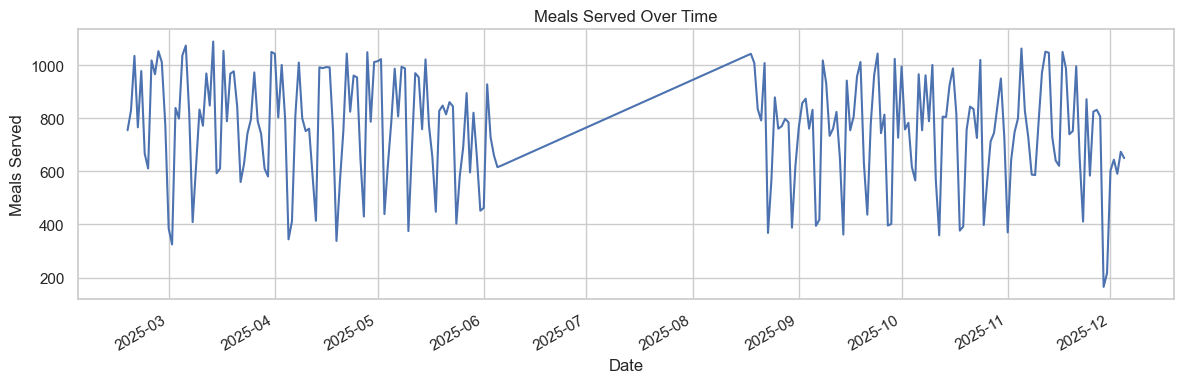

Interpretation: The line plot reveals a repeating pattern of dips (often on weekends) and peaks (weekdays), and possible drops during exam periods. This suggests day-of-week and academic calendar events strongly influence demand.


In [ ]:
# =============================================================================

# =============================================================================
# Sort by date so the line plot shows the correct time order.
df_sorted = df.sort_values('Date')

plt.figure(figsize=(12, 4))
sns.lineplot(data=df_sorted, x='Date', y='Meals_Served')
plt.title('Meals Served Over Time')
plt.xlabel('Date')
plt.ylabel('Meals Served')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


#### 2. DATA PREPARATION (PREPROCESSING) - Drop Unused Columns

In [ ]:
# Work on a copy so we keep the original df for reference.
df_ml = df.copy()

# Dropping columns not useful for the model:
# - Date: raw dates are not used as a feature (we use Day_of_Week and Semester instead).
# - Full_Menu: redundant with Starch, Protein, Side combined.
# - Weekday_Type: was only for EDA; the model will use one-hot encoded Day_of_Week.
df_ml = df_ml.drop(columns=['Date', 'Full_Menu', 'Weekday_Type'])

print("Columns after dropping:", list(df_ml.columns))

Columns after dropping: ['Day_of_Week', 'Semester', 'Starch', 'Protein', 'Side', 'Academic_Event', 'Meals_Served']


#### Preprocessing: One-Hot Encoding of Categorical Variables

In [ ]:
# drop_first=True reduces multicollinearity (one category is the reference).
cat_columns = ['Day_of_Week', 'Starch', 'Protein', 'Side', 'Academic_Event']
df_encoded = pd.get_dummies(df_ml, columns=cat_columns, drop_first=True)

# Features X: all columns except the target. Target y: Meals_Served.
y = df_ml['Meals_Served'].values
X = df_encoded.drop(columns=['Meals_Served'])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (220, 13)
Target shape: (220,)


#### Preprocessing: Train/Test Split (80% train, 20% test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(y_train)} samples")
print(f"Testing set size:  {len(y_test)} samples")

Training set size: 176 samples
Testing set size:  44 samples


#### 3. MODEL BUILDING & TRAINING

In [ ]:
model = RandomForestRegressor(random_state=42, n_estimators=100)

# Fit only on training data to avoid overfitting; test set is held out for evaluation.
model.fit(X_train, y_train)

print("Model trained successfully on the training set.")

Model trained successfully on the training set.


In [11]:
# =============================================================================
# 4. MODEL EVALUATION - Predictions and Metrics
# =============================================================================
# Predict on the held-out test set (model has never seen these samples).
y_pred = model.predict(X_test)

# Mean Absolute Error: average absolute difference between actual and predicted meals.
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", round(mae, 2))

# R-squared: proportion of variance in Meals_Served explained by the model (0 to 1, higher is better).
r2 = r2_score(y_test, y_pred)
print("R-squared (R²):", round(r2, 4))

Mean Absolute Error (MAE): 32.17
R-squared (R²): 0.9687


#### Points close to the red diagonal line indicate accurate predictions. Spread around the line shows the size of prediction errors.

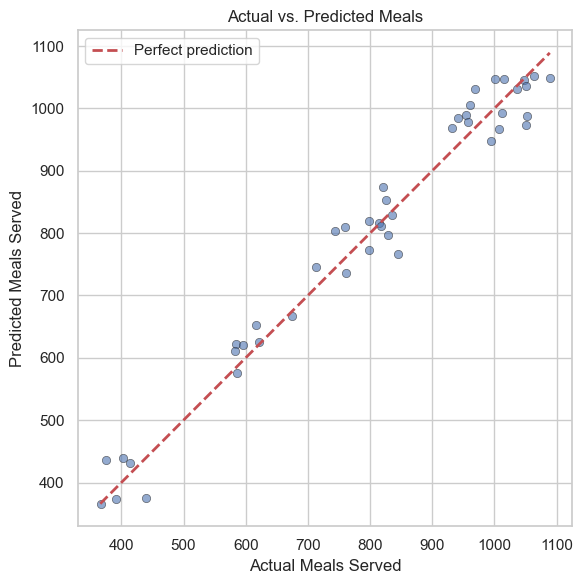

Interpretation: Points close to the red diagonal line indicate accurate predictions. Spread around the line shows the size of prediction errors.


In [ ]:
# =============================================================================
# Evaluation: Actual vs. Predicted Scatter Plot
# =============================================================================
# Points on the diagonal line would be perfect predictions.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.5)

# Reference line: perfect prediction (y_pred = y_actual).
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

plt.xlabel('Actual Meals Served')
plt.ylabel('Predicted Meals Served')
plt.title('Actual vs. Predicted Meals')
plt.legend()
plt.tight_layout()
plt.show()
